In [1]:
%matplotlib widget
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import scipy
import h5py

import os
import sys
sys.path.append(os.path.abspath("./"))

print(os.getpid())
%cd ../../

import pylib.mix as mix
import carleman as ca
from matplotlib import colors
plt.rcParams.update({
    "text.usetex": True,
    'text.latex.preamble': r"\usepackage{amsmath} \boldmath"
})

7912
c:\Users\ivan9\Documents\work\codes\QuCF\scripts-py


In [2]:
path_save_ = "./jupyter-notebooks/Carleman/results/"
for i in range(100):
    plt.close()

colors_     = ["blue", "red", "green", "gray", "black"]
linestyles_ = ["-", "--", "--", ":"]

init. cond.:   0.20   0.20   0.20 




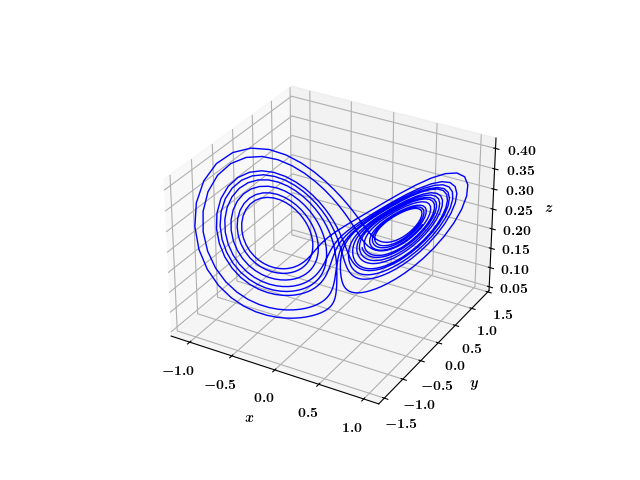

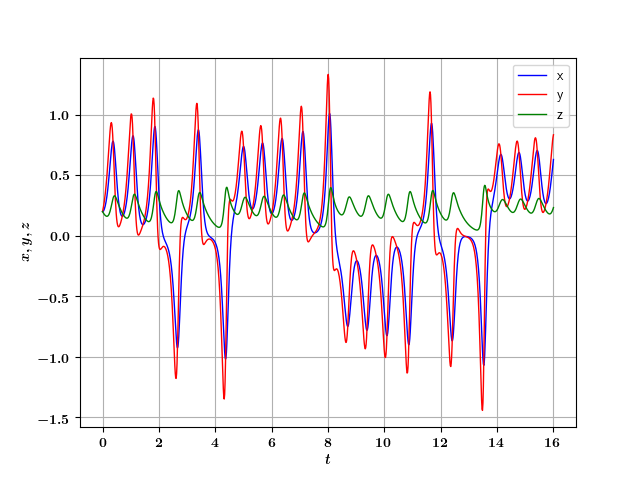

In [3]:
# ---------------------------------------------------------------
# --- Prepare the system ---
# ---------------------------------------------------------------
mix.reload_module(ca)
mix.reload_module(mix)
def choose_case(N_nl, sel_case):
    Nx = 3  # the number of degrees of freedom

    sys_coefs, return_sys, shift_coefs = None, None, None

    F_terms = [None] * (N_nl + 1)
    for ii_nl in range(N_nl + 1):
        F_terms[ii_nl] = np.zeros((Nx,int(Nx**ii_nl)))

    # ----------------------------------------------------------
    # --- Lorentz attractor ---
    if sel_case == 0:
        tmax, nt = 16, 10
        # tmax, nt = 32, 11

        ss, rr, bb = 10., 28, 8./3.  
        cx, cz = 2., 4. 
        xi_x, xi_y, xi_z = 0.0, 0.0, 0.0
        x_init = np.array([0.2, 0.2, 0.2])

        sys_coefs = {}
        sys_coefs["ss"]   = ss
        sys_coefs["rr"]   = rr
        sys_coefs["bb"]   = bb
        sys_coefs["xi_x"] = xi_x
        sys_coefs["xi_y"] = xi_y
        sys_coefs["xi_z"] = xi_z
        sys_coefs["cx"]   = cx
        sys_coefs["cz"]   = cz

        # -------------------------------------------------------------
        def return_sys(ss_coefs):
            ss   = ss_coefs["ss"]    
            rr   = ss_coefs["rr"]    
            bb   = ss_coefs["bb"]    
            xi_x = ss_coefs["xi_x"]  
            xi_y = ss_coefs["xi_y"]  
            xi_z = ss_coefs["xi_z"]  
            cx   = ss_coefs["cx"]    
            cz   = ss_coefs["cz"] 

            eta_x_2 = cx**2 * bb * (rr - 1)
            eta_z = cz*(rr - 1)
            eta = eta_x_2 / eta_z 

            F_terms = [None] * (N_nl + 1)
            for ii_nl in range(N_nl + 1):
                F_terms[ii_nl] = np.zeros((Nx,int(Nx**ii_nl)))

            # *** matrix F0 ***
            F_terms[0][0,0] = ss * (xi_y - xi_x)
            F_terms[0][1,0] = rr*xi_x - xi_y - eta_z*xi_x*xi_z
            F_terms[0][2,0] = eta*xi_x*xi_y - bb*xi_z

            # *** matrix F1 ***
            F_terms[1][0,0], F_terms[1][0,1] = -ss, ss
            F_terms[1][1,0], F_terms[1][1,1], F_terms[1][1,2] = rr - eta_z*xi_z,       -1, -eta_z*xi_x
            F_terms[1][2,0], F_terms[1][2,1], F_terms[1][2,2] =        eta*xi_y, eta*xi_x,         -bb 

            # *** matrix F2 ***
            F_terms[2][1,2] = - eta_z
            F_terms[2][2,1] = eta

            return F_terms
        
        # -------------------------------------------------------------
        def shift_coefs(ss, zeta):
            ss_new = dict(ss)
            ss_new["xi_x"] = ss_new["xi_x"] + zeta[0]
            ss_new["xi_y"] = ss_new["xi_y"] + zeta[1]
            if "xi_z" in ss_new:
                ss_new["xi_z"] = ss_new["xi_z"] + zeta[2]
            return ss_new

        # --- construct the system ---
        F_terms = return_sys(sys_coefs)
        F = [
            lambda x: F_terms[0][0,0] + F_terms[1][0,0] * x[0] + F_terms[1][0,1] * x[1],
            lambda x: F_terms[0][1,0] + F_terms[1][1,0] * x[0] + F_terms[1][1,1] * x[1] + F_terms[1][1,2] * x[2] + F_terms[2][1,2] * x[0] * x[2],
            lambda x: F_terms[0][2,0] + F_terms[1][2,0] * x[0] + F_terms[1][2,1] * x[1] + F_terms[1][2,2] * x[2] + F_terms[2][2,1] * x[0] * x[1]
        ]

    # ----------------------------------------------------
    return F, tmax, nt, Nx, x_init, F_terms, sys_coefs, return_sys, shift_coefs
# ------------------------------------------------------------------------------
sel_case_ = 0

N_nl_orig_ = 2
F_, tmax_, nt_, Nx_, x_init_ref_, F_terms_, sys_coefs_, return_sys_, shift_coefs_ = choose_case(N_nl_orig_, sel_case = sel_case_)
Nt_ = 1 << nt_
t_ = np.linspace(0, tmax_, Nt_)
dt_ = np.diff(t_)[0]

print("init. cond.: ", end = "")
mix.print_array(x_init_ref_, ff = [6, 2, "f"])

# --- Standard method (for reference) ---
sol_ref_, t_ref_ = ca.analyse_classical(x_init_ref_, t_, F_)

In [90]:
# --------------------------------------------------------------------
# --- Carleman linearization ---
# --------------------------------------------------------------------
mix.reload_module(ca)
N_nl = 6   # should be >= N_nl_orig_


# -----------------------------------------------------
# --- Static embedding ---
# X_GC_ = np.array([1.0 / np.sqrt(Nx_)] * 3)
# Zeta_ = np.array([ 1.0 / np.sqrt(Nx_) ]*Nx_)

# # --- case 1 ---
X_GC_ = np.array([0.0, 0.0, 0.0])

Zeta_ = np.array([0.4 / np.sqrt(Nx_) ]*Nx_)
# Zeta_ = np.array([0.3 / np.sqrt(Nx_) ]*Nx_)
# Zeta_ = np.array([0.2 / np.sqrt(Nx_) ]*Nx_)
# Zeta_ = np.array([0.1 / np.sqrt(Nx_) ]*Nx_)

# --- case 2 ---
# xi_1 = 0.9 / np.sqrt(Nx_)
# xi_1 = 0.5 / np.sqrt(Nx_)
# xi_1 = 0.3 / np.sqrt(Nx_)
# xi_1 = 0.2 / np.sqrt(Nx_)
# xi_1 = 0.1 / np.sqrt(Nx_)

# X_GC_ = np.array([0.0, 0.0, xi_1 ])
# Zeta_ = np.array([xi_1]*Nx_)
# del xi_1

# --- case 3 ---
# X_GC_ = np.array([0.5, 0.5, 0.50])

# Zeta_ = np.array([0.4]*Nx_)
# Zeta_ = np.array([0.2]*Nx_)
# Zeta_ = np.array([0.1]*Nx_)


# -----------------------
case_sim_ = "LA_init{:0.1f}_{:0.1f}_{:0.1f}_GC{:0.1f}_{:0.1f}_{:0.1f}_xi{:0.3f}".format(
    x_init_ref_[0], x_init_ref_[1], x_init_ref_[2],
    X_GC_[0], X_GC_[1], X_GC_[2], 
    Zeta_[0]
)

print("case sim: {:s}".format(case_sim_))
print()

sol_emb_, t_emb_, case_emb_ = ca.solve_carleman_global_fixed(
    x_init_ref_, N_nl, N_nl_orig_, t_, 
    sys_coefs_, return_sys_, shift_coefs_,
    X_GC_, Zeta_
)
GCE_grid = ca.print_GCE_grid(X_GC_, Zeta_, max_v = 1.49)
del X_GC_, Zeta_

case sim: LA_init0.2_0.2_0.2_GC0.0_0.0_0.0_xi0.231

The total number of variables in the embedding: 1092

Done


 ----------------------------------------------
--- GCE grid ---
----------------------------------------------
center: 
     0.000e+00      0.000e+00      0.000e+00 
sizes: 
     2.309e-01      2.309e-01      2.309e-01 

--- x ---
    -2.078e+00     -1.617e+00     -1.155e+00     -6.928e-01     -2.309e-01      2.309e-01      6.928e-01      1.155e+00      1.617e+00      2.309e+00 
--- y ---
    -2.078e+00     -1.617e+00     -1.155e+00     -6.928e-01     -2.309e-01      2.309e-01      6.928e-01      1.155e+00      1.617e+00      2.309e+00 
--- z ---
    -2.078e+00     -1.617e+00     -1.155e+00     -6.928e-01     -2.309e-01      2.309e-01      6.928e-01      1.155e+00      1.617e+00      2.309e+00 


write data to a file: ./jupyter-notebooks/Carleman/results//REF_LA_init0.2_0.2_0.2_GC0.0_0.0_0.0_xi0.231_xyz.dat
write data to a file: ./jupyter-notebooks/Carleman/results//EMB_LA_init0.2_0.2_0.2_GC0.0_0.0_0.0_xi0.231_GCE_xyz.dat
write data to a file: ./jupyter-notebooks/Carleman/results//REF_LA_init0.2_0.2_0.2_GC0.0_0.0_0.0_xi0.231_x.dat
write data to a file: ./jupyter-notebooks/Carleman/results//EMB_LA_init0.2_0.2_0.2_GC0.0_0.0_0.0_xi0.231_GCE_x.dat
write data to a file: ./jupyter-notebooks/Carleman/results//REF_LA_init0.2_0.2_0.2_GC0.0_0.0_0.0_xi0.231_y.dat
write data to a file: ./jupyter-notebooks/Carleman/results//EMB_LA_init0.2_0.2_0.2_GC0.0_0.0_0.0_xi0.231_GCE_y.dat
write data to a file: ./jupyter-notebooks/Carleman/results//REF_LA_init0.2_0.2_0.2_GC0.0_0.0_0.0_xi0.231_z.dat
write data to a file: ./jupyter-notebooks/Carleman/results//EMB_LA_init0.2_0.2_0.2_GC0.0_0.0_0.0_xi0.231_GCE_z.dat
write data to a file: ./jupyter-notebooks/Carleman/results//EMB_LA_init0.2_0.2_0.2_GC0.0_0.0

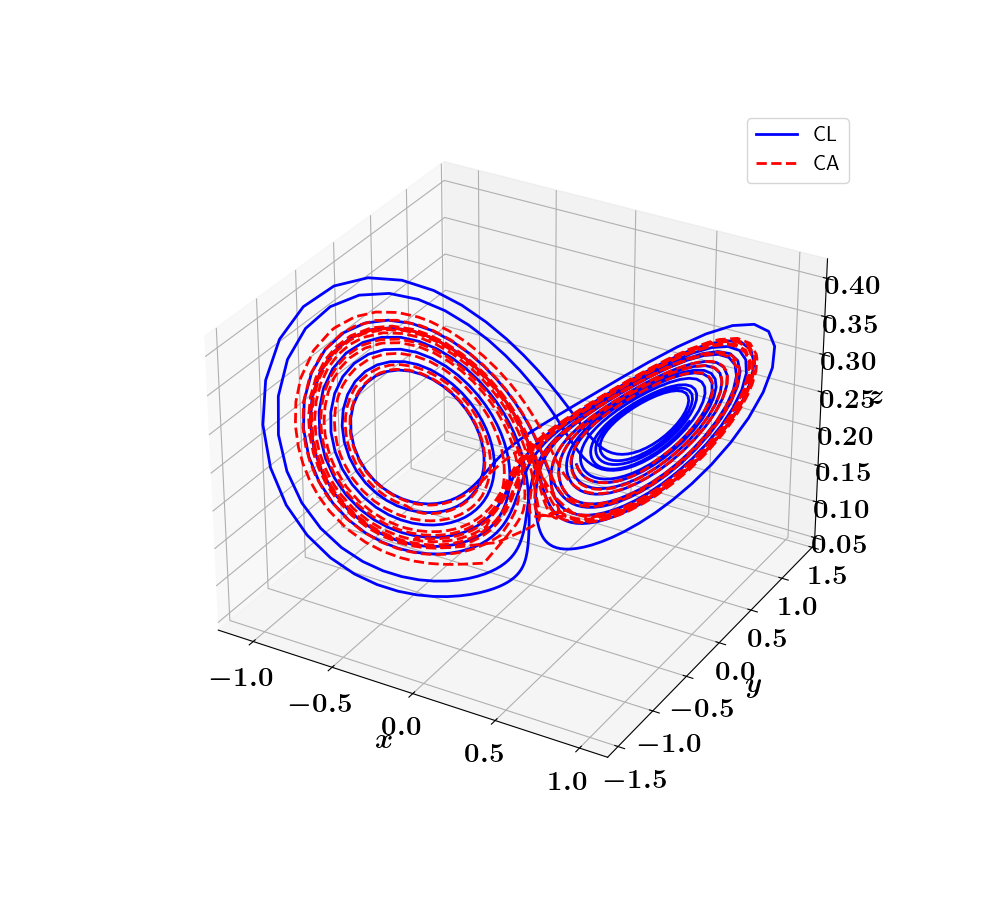

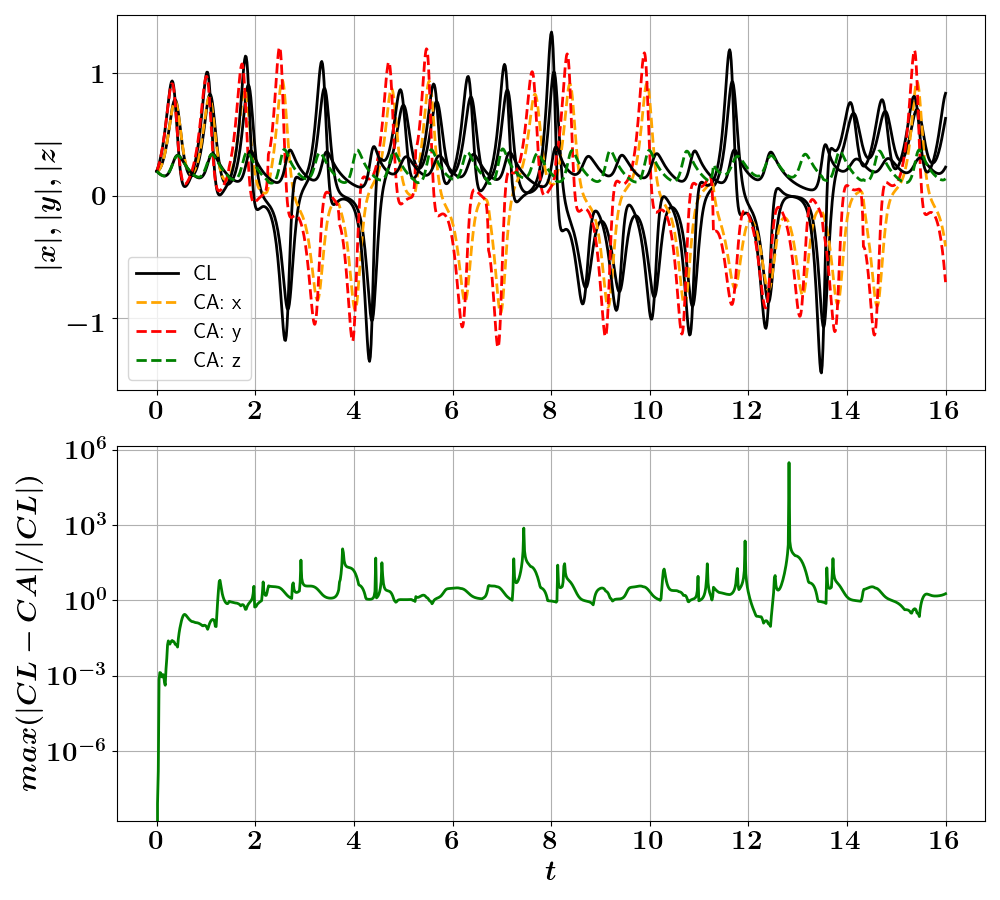

In [91]:
# --------------------------------------------------------------------
# --- Compare trajectories ---
# --------------------------------------------------------------------
mix.reload_module(ca)
ca.compare_trajectory_cl_and_carleman(
    t_ref_, sol_ref_, t_emb_, sol_emb_,
    flag_save=True, 
    path_save=path_save_, 
    case_title = case_sim_, case_emb = case_emb_,
    fontsize = 20, fig_size = (10,9),
    flag_var_semilogy = False,
    flag_max_error = True
)